<a href="https://colab.research.google.com/github/jaydenxaf/Adversarial-Image-Sandbox/blob/main/Adversarial_Image_Sandbox.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install --upgrade keras

In [ ]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

In [ ]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

In [ ]:
# Import the cifar10 dataset
from keras.datasets import cifar10

# Set the training and test images + labels
(train_images, train_labels), (test_images, test_labels) = cifar10.load_data()

In [ ]:
import keras
from keras import layers

# Create a stack of layers
model = keras.Sequential(
    [
        # Create a tensor in the shape of a 32x32 grid with three color channels for RGB
        keras.Input(shape=(32, 32, 3)),

        # A conv2D layer -- 32 kernels which scan the image in 3x3 grids to detect patterns
        layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
        # Takes the max value over an input to downsample it for performance
        layers.MaxPooling2D(pool_size=(2, 2)),

        # A conv2D layer -- Uses 64 kernels to detect complex shapes from the simplified maps
        layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        # Shrinks the spatial dimensions even further
        layers.MaxPooling2D(pool_size=(2, 2)),

        # Flattens the input
        layers.Flatten(),
        # Densely-connected -- outputs input if positive, else returns zero
        layers.Dense(64, activation="relu"),
        # Transforms output to a probability distribution
        layers.Dense(10, activation="softmax")
    ]
)

In [ ]:
model.compile(
    # Uses the "adam" optimizer to update itself
    optimizer="adam",
    # Measures the performance of the training data
    loss="sparse_categorical_crossentropy",
    # Used to monitor performance
    metrics=["accuracy"]
)

In [ ]:
# Train model and save the history
history = model.fit(
    train_images,
    train_labels,
    batch_size=64,
    epochs=10,
    validation_data=(test_images, test_labels)
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 72s 88ms/step - accuracy: 0.3386 - loss: 2.4552 - val_accuracy: 0.4517 - val_loss: 1.5398
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 57s 73ms/step - accuracy: 0.5096 - loss: 1.3783 - val_accuracy: 0.5418 - val_loss: 1.2826
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 59s 75ms/step - accuracy: 0.5813 - loss: 1.1916 - val_accuracy: 0.5773 - val_loss: 1.2212
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 77ms/step - accuracy: 0.6289 - loss: 1.0589 - val_accuracy: 0.6164 - val_loss: 1.1223
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 79s 72ms/step - accuracy: 0.6627 - loss: 0.9716 - val_accuracy: 0.6337 - val_loss: 1.0876
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 82s 72ms/step - accuracy: 0.6916 - loss: 0.8883 - val_accuracy: 0.6152 - val_loss: 1.1696
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 54s 69ms/step - accuracy: 0.7148 - loss: 0.8247 - val_accuracy: 0.6366 - val_loss: 1.1269
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 53s 68ms/step - accuracy: 0.7324 - loss: 0.7643 - 

In [ ]:
# Evaluate how accurate the model is
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f"Final Test Accuracy: {test_acc}")

313/313 - 4s - 14ms/step - accuracy: 0.6545 - loss: 1.1235
Final Test Accuracy: 0.6545000076293945


In [ ]:
# Making a Prediction
import numpy as np

# Order of the 10 classes in the dataset
cifar10_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Retrieves the first test image
image_to_predict = test_images[0]

# Reshape the test image
image_batch = np.expand_dims(image_to_predict, axis=0)

# Have model predict what the test image is
raw_predictions = model.predict(image_batch)

# Find the class with the highest probability (what the model thinks the image is)
predicted_class = np.argmax(raw_predictions[0])

print(f"Raw Output Probabilities: {raw_predictions[0]}")
print(f"The model confidently predicts this is a: {cifar10_classes[predicted_class]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
Raw Output Probabilities: [1.2814500e-03 3.9771890e-05 6.8622513e-04 7.4532419e-01 3.6295007e-03
 2.3823248e-01 1.5880176e-03 8.5747028e-03 4.8575472e-04 1.5793747e-04]
The model confidently predicts this is a: cat


In [ ]:
import numpy as np
from keras.preprocessing import image

# Order of the 10 classes in the dataset
cifar10_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Upload image
img = image.load_img("/airplane.jpg", target_size=(32, 32))

# Test image
image_to_predict = image.img_to_array(img)

# Reshape image
image_batch = np.expand_dims(image_to_predict, axis=0)

# Run model on test image
raw_predictions = model.predict(image_batch)

# Find class with highest probability
predicted_class = np.argmax(raw_predictions[0])

print(f"Raw Output Probabilities: {raw_predictions[0]}")
print(f"The model confidently predicts this is a: {cifar10_classes[predicted_class]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
Raw Output Probabilities: [9.9744570e-01 6.4767505e-07 2.1674049e-03 5.7743800e-05 2.1332327e-05
 2.6662115e-06 6.8015856e-05 1.6092275e-07 2.3256242e-04 3.8709809e-06]
The model confidently predicts this is a: airplane


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


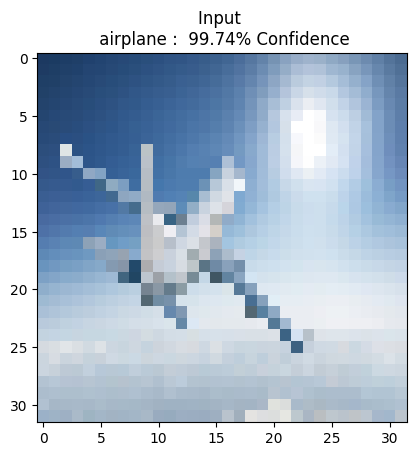

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


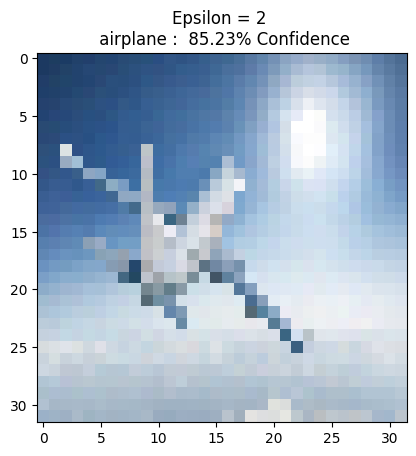

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


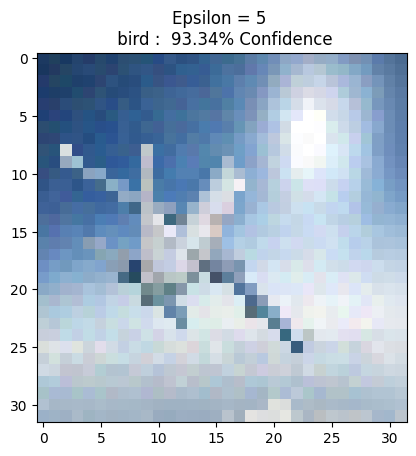

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


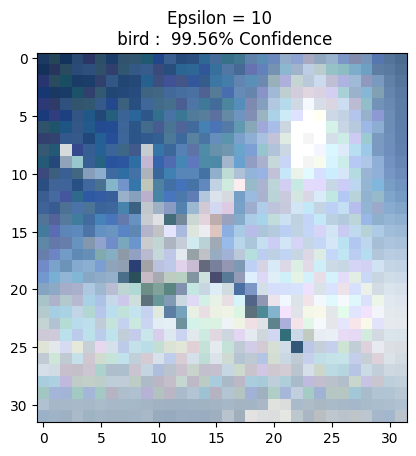

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


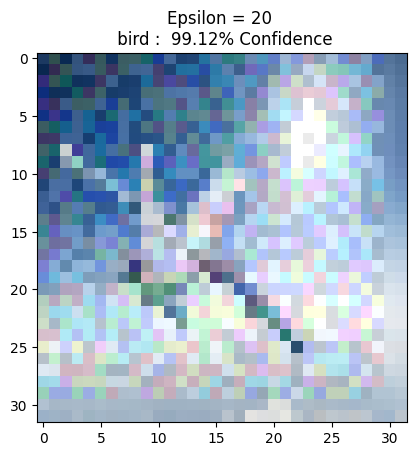

In [ ]:
## Phase 2 - Fast Gradient Signed Method Attack
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# Update loss for CIFAR-10 integers
loss_object = tf.keras.losses.SparseCategoricalCrossentropy()

def create_adversarial_pattern(input_image, input_label):
  with tf.GradientTape() as tape:
    # Tape watches the image's pixels
    tape.watch(input_image)
    prediction = model(input_image)
    loss = loss_object(input_label, prediction)

  # Get gradient of loss w.r.t the input image
  gradient = tape.gradient(loss, input_image)

  # Get the sign of the gradients to create the pertubation
  signed_grad = tf.sign(gradient)
  return signed_grad

def display_images(image, description):

  # Get prediction using model
  raw_predictions = model.predict(image)

  # Find index and confidence of the highest guess
  predicted_index = np.argmax(raw_predictions[0])
  confidence = raw_predictions[0][predicted_index]

  # Class with highest probability
  label = cifar10_classes[predicted_index]

  # Display as 2d image
  plt.figure()
  # Divide by 255 because Matplotlib prefers floats btw 0-1
  plt.imshow(image[0] / 255.0)
  plt.title('{} \n {} :  {:.2f}% Confidence'.format(description,
                                                    label, confidence * 100))
  plt.show()

# Convert image to tensor
image_tensor = tf.convert_to_tensor(image_batch, dtype=tf.float32)

# Create the pertubation (input is the image tensor and its true label)
perturbations = create_adversarial_pattern(image_tensor, tf.constant([0]))

epsilons = [0, 2, 5, 10, 20]
descriptions = [('Epsilon = {}'.format(eps) if eps else 'Input')
                for eps in epsilons]

# Breaking point @ epsilon 5
for i, eps in enumerate(epsilons):
  # Add noise to image
  adv_x = image_tensor + (eps * perturbations)

  # Clip pixels so they stay valid colors
  adv_x = tf.clip_by_value(adv_x, 0, 255)

  display_images(adv_x, descriptions[i])

In [ ]:
# Generate the defense dataset
import numpy as np

eps = 5
adv_imgs = []
adv_labels = []
for i  in range(1000):
  img = train_images[i]
  label = train_labels[i]

  # Reshape image
  image_batch = np.expand_dims(img, axis=0)

  # Convert image to tensor
  image_tensor = tf.convert_to_tensor(image_batch, dtype=tf.float32)

  # Create perturbation
  perturbation = create_adversarial_pattern(image_tensor, tf.constant([label]))

  # Add the noise to image
  adv_x = image_tensor + (eps * perturbation)

  # Clip pixels
  adv_x = tf.clip_by_value(adv_x, 0, 255)

  # Add images and label to defense dataset
  # Strip the batch dimension by taking index 0
  adv_imgs.append(adv_x[0])
  adv_labels.append(label)

# Convert lists into numpy arrays
adv_imgs = np.array(adv_imgs)
adv_labels = np.array(adv_labels)

print(f"Successfully generated {len(adv_imgs)} adversarial images!")

Successfully generated 1000 adversarial images!


In [ ]:
## Phase 3 - Vaccine
import numpy as np

clean_imgs = train_images[1000:2000]
clean_labels = train_labels[1000:2000]

combined_imgs = np.concatenate((adv_imgs, clean_imgs))
combined_labels = np.concatenate((adv_labels, clean_labels))

indices = np.arange(len(combined_imgs))
np.random.shuffle(indices)

shuffled_imgs = combined_imgs[indices]
shuffled_labels = combined_labels[indices]

print(f"Vaccine mix ready! Total images: {len(shuffled_imgs)}")

Vaccine mix ready! Total images: 2000


In [ ]:
model.fit(shuffled_imgs, shuffled_labels, batch_size=64, epochs=4, validation_data=(test_images, test_labels))

Epoch 1/4
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 151ms/step - accuracy: 0.3590 - loss: 2.0614 - val_accuracy: 0.4569 - val_loss: 1.5508
Epoch 2/4
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 145ms/step - accuracy: 0.4390 - loss: 1.5197 - val_accuracy: 0.5312 - val_loss: 1.3541
Epoch 3/4
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 188ms/step - accuracy: 0.5415 - loss: 1.2545 - val_accuracy: 0.5583 - val_loss: 1.2958
Epoch 4/4
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 186ms/step - accuracy: 0.6090 - loss: 1.0609 - val_accuracy: 0.5653 - val_loss: 1.3021


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


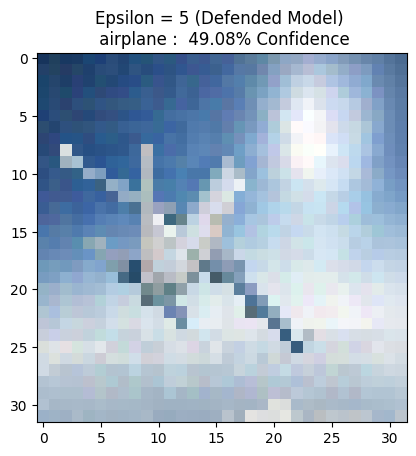

In [ ]:
img = image.load_img("/airplane.jpg", target_size=(32, 32))

image_to_predict = image.img_to_array(img)

image_batch = np.expand_dims(image_to_predict, axis=0)

# Convert image to a tensor
image_tensor = tf.convert_to_tensor(image_batch, dtype=tf.float32)

# Generate an adversarial pattern based on new model's gradients
perturbations = create_adversarial_pattern(image_tensor, tf.constant([0]))

# Apply the exact same Epsilon = 5 noise that broke the model
eps = 5
adv_x = image_tensor + (eps * perturbations)
adv_x = tf.clip_by_value(adv_x, 0, 255)

# Display the image and the new model's prediction!
display_images(adv_x, 'Epsilon = 5 (Defended Model)')

In [ ]:
model.save('defended_model.keras')